In [1]:
import numpy as np

rng = np.random.default_rng(0)

In [2]:
''' Возьмем простые данные - n-мерное изотропное нормальное распределение N(0, I_d) '''

def logp(x):
    return -0.5 * np.dot(x, x)

def grad_logp(x):
    return -x

def your_data_utils():
    """
    Двумодальное распределение: две очень узкие, сильно разнесённые гауссианы.
    """
    sigma = 0.5
    sigma2 = sigma * sigma

    def logp_factory(x):
        d = len(x)
        mu1 = np.zeros(d); mu1[0] = 8.0
        mu2 = np.zeros(d); mu2[0] = -8.0

        diff1 = x - mu1
        diff2 = x - mu2
        log1 = -0.5 / sigma2 * np.dot(diff1, diff1)
        log2 = -0.5 / sigma2 * np.dot(diff2, diff2)
        m = max(log1, log2)
        return m + np.log(0.5 * np.exp(log1 - m) + 0.5 * np.exp(log2 - m))

    def grad_factory(x):
        d = len(x)
        mu1 = np.zeros(d); mu1[0] = 8.0
        mu2 = np.zeros(d); mu2[0] = -8.0

        diff1 = x - mu1
        diff2 = x - mu2
        log1 = -0.5 / sigma2 * np.dot(diff1, diff1)
        log2 = -0.5 / sigma2 * np.dot(diff2, diff2)
        m = max(log1, log2)
        w1 = np.exp(log1 - m)
        w2 = np.exp(log2 - m)
        s = (w1 + w2)
        w1 /= s
        w2 /= s
        g = -(1.0 / sigma2) * (w1 * diff1 + w2 * diff2)
        return g

    return logp_factory, grad_factory

In [3]:
''' Посчитаем ESS через интегрированную автокорреляции '''

def ess(x):
    x = x - x.mean()
    acf = np.correlate(x, x, mode='full')
    acf = acf[len(acf) // 2:]
    acf /= (acf[0] + 1e-16)
    maxlag = min(200, len(acf)-1)
    tau = 1 + 2 * np.sum(acf[1:maxlag])
    return len(x) / tau

In [4]:
def acf_vals(x, maxlag=200):
    x = x - x.mean()
    acf = np.correlate(x, x, mode='full')
    acf = acf[len(acf)//2:]
    acf /= (acf[0] + 1e-16)
    return acf[:maxlag]

In [5]:
''' Базовая реализация MH алгоритма '''

def mh(x0, steps, scale, logp_fun):
    x = x0.copy()
    d = len(x)
    chain = np.zeros((steps, d))
    accept = 0
    for t in range(steps):
        prop = x + rng.normal(0, scale, size=d)
        if np.log(rng.uniform()) < (logp_fun(prop) - logp_fun(x)):
            x = prop
            accept += 1
        chain[t] = x
    return chain, accept / steps

In [6]:
# Тут нужно заимплементить Metropolis Adjusted Langevin Algorithm (MALA)

def mala(x0, steps, step, logp_fun, grad_logp_fun):
    x = x0.copy()
    d = len(x)
    chain = np.zeros((steps, d))
    accept = 0
    eps = step
    for t in range(steps):
        grad = grad_logp_fun(x)
        mu = x + 0.5 * eps**2 * grad
        prop = mu + rng.normal(0, eps, size=d)
        log_q_x_given_prop = -0.5 / (eps**2) * np.sum(
            (x - (prop + 0.5 * eps**2 * grad_logp_fun(prop)))**2
        )
        log_q_prop_given_x = -0.5 / (eps**2) * np.sum(
            (prop - (x + 0.5 * eps**2 * grad))**2
        )
        logalpha = logp_fun(prop) + log_q_x_given_prop - logp_fun(x) - log_q_prop_given_x
        if np.log(rng.uniform()) < logalpha:
            x = prop
            accept += 1
        chain[t] = x
    return chain, accept / steps

In [7]:
d = 10
steps = 30000
burn = 5000
x0 = np.ones(d) * 3.0

logp_mix, grad_logp_mix = your_data_utils()

mh_scale = 0.8
mala_step = 0.6

mh_chain_g, mh_acc_g = mh(x0, steps, scale=mh_scale, logp_fun=logp)
mala_chain_g, mala_acc_g = mala(x0, steps, step=mala_step, logp_fun=logp, grad_logp_fun=grad_logp)

mh_chain_mix, mh_acc_m = mh(x0, steps, scale=mh_scale, logp_fun=logp_mix)
mala_chain_mix, mala_acc_m = mala(x0, steps, step=mala_step, logp_fun=logp_mix, grad_logp_fun=grad_logp_mix)

def median_ess(chain, burn):
    trimmed = chain[burn:]
    ess_vals = [ess(trimmed[:, i]) for i in range(trimmed.shape[1])]
    return np.median(ess_vals), ess_vals

mh_ess_g_med, _ = median_ess(mh_chain_g, burn)
mala_ess_g_med, _ = median_ess(mala_chain_g, burn)
mh_ess_m_med, _ = median_ess(mh_chain_mix, burn)
mala_ess_m_med, _ = median_ess(mala_chain_mix, burn)

print("=== Gaussian target ===")
print(f"MH acceptance = {mh_acc_g:.3f}, median ESS = {mh_ess_g_med:.1f}")
print(f"MALA acceptance = {mala_acc_g:.3f}, median ESS = {mala_ess_g_med:.1f}")
print()
print("=== Mixture of Gaussians target ===")
print(f"MH acceptance = {mh_acc_m:.3f}, median ESS = {mh_ess_m_med:.1f}")
print(f"MALA acceptance = {mala_acc_m:.3f}, median ESS = {mala_ess_m_med:.1f}")

=== Gaussian target ===
MH acceptance = 0.236, median ESS = 850.6
MALA acceptance = 0.929, median ESS = 2411.7

=== Mixture of Gaussians target ===
MH acceptance = 0.029, median ESS = 241.0
MALA acceptance = 0.508, median ESS = 6580.5


In [8]:
# Здесь нарисуйте 3 графика: trace plot (значение цепи vs итерация),
# график автокорреляции (значение ACF vs задержка по времени) и гистограмма семплов (возьмите какую-то одну размерность)

import matplotlib.pyplot as plt


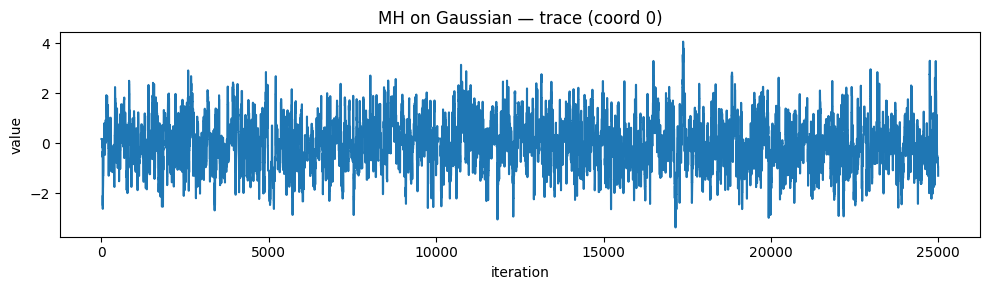

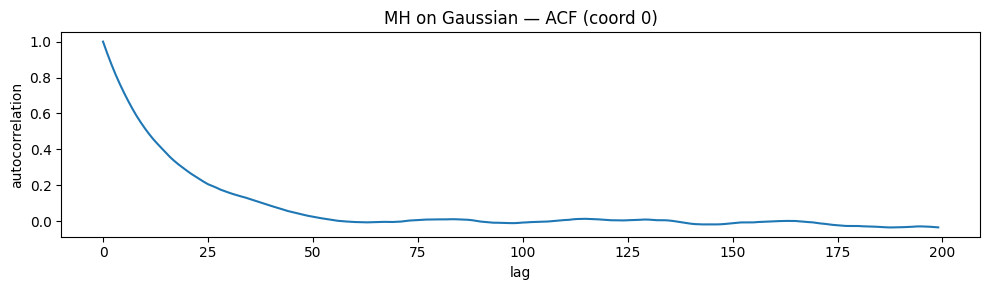

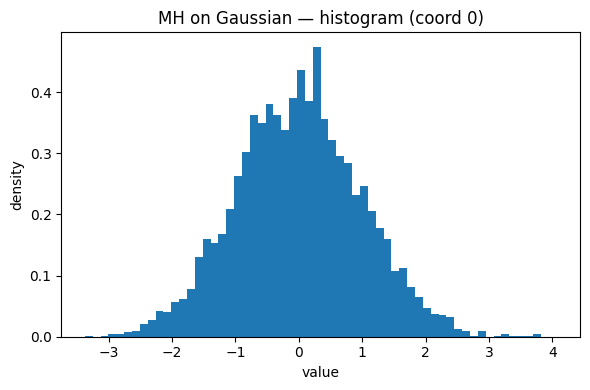

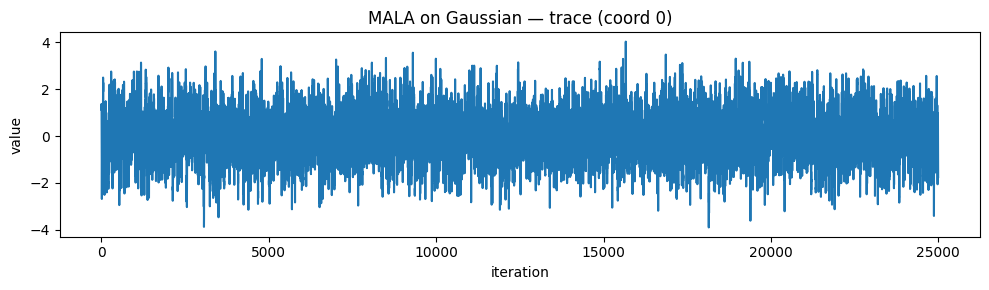

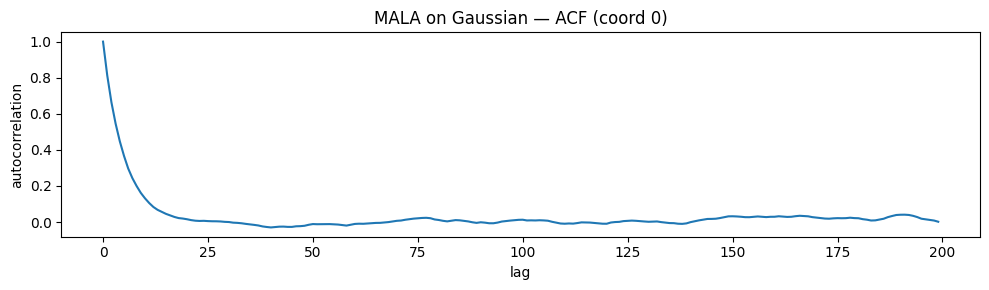

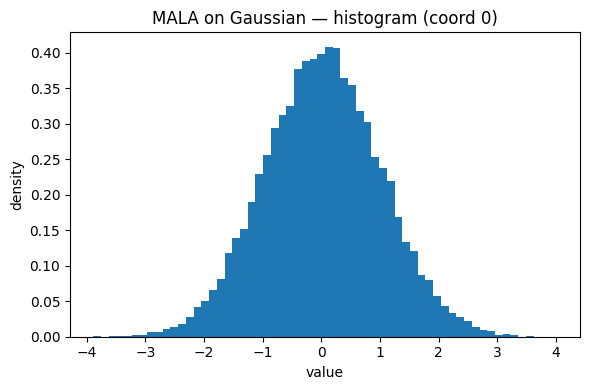

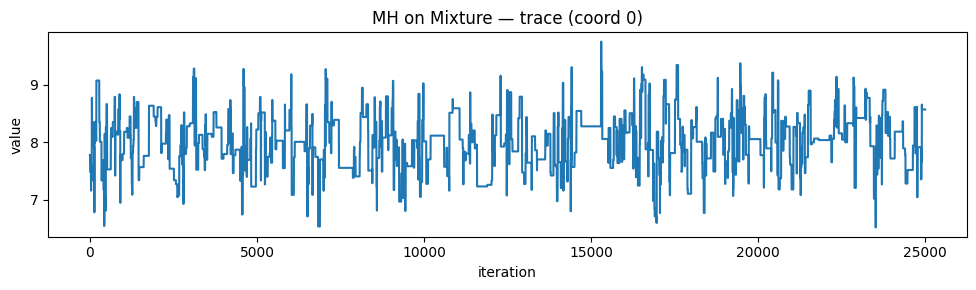

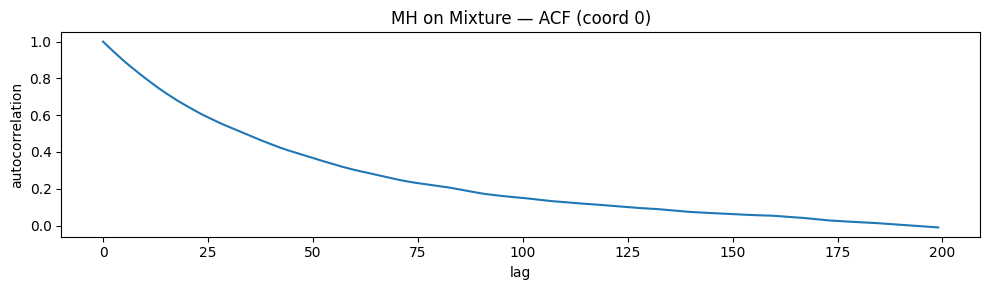

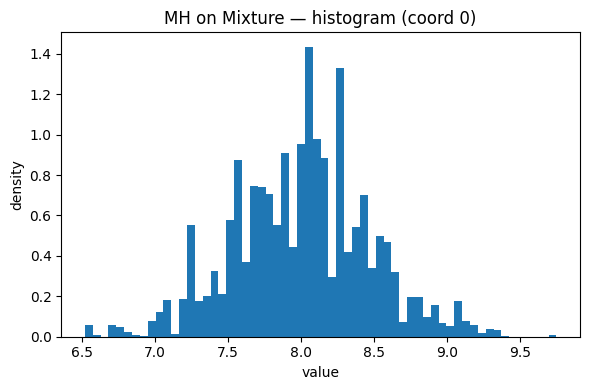

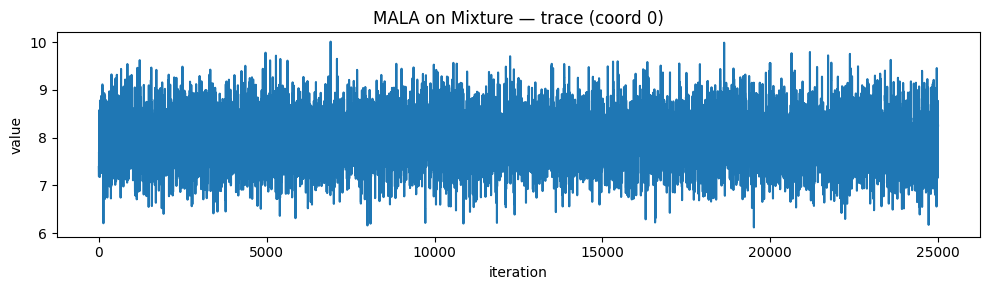

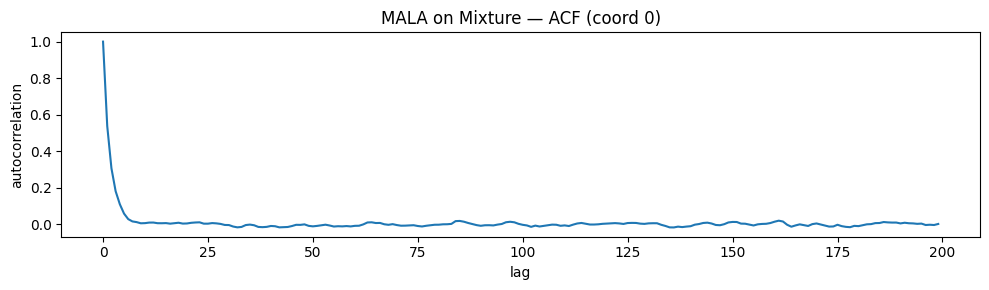

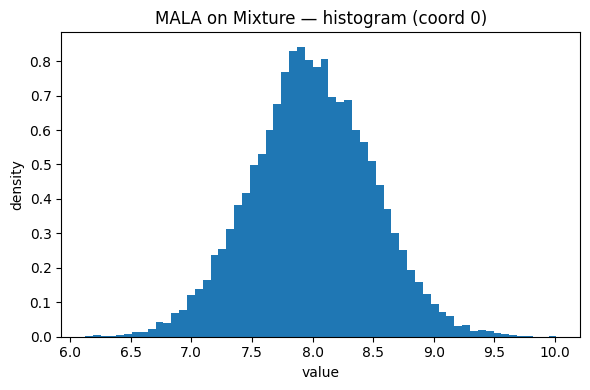

In [9]:
coord = 0

def plot_chain_analysis(chain, title_prefix):
    trimmed = chain[burn:]
    series = trimmed[:, coord]

    # trace
    plt.figure(figsize=(10,3))
    plt.plot(series)
    plt.title(f"{title_prefix} — trace (coord {coord})")
    plt.xlabel("iteration")
    plt.ylabel("value")
    plt.tight_layout()
    plt.show()

    # ACF
    plt.figure(figsize=(10,3))
    plt.plot(acf_vals(series, maxlag=200))
    plt.title(f"{title_prefix} — ACF (coord {coord})")
    plt.xlabel("lag")
    plt.ylabel("autocorrelation")
    plt.tight_layout()
    plt.show()

    # histogram
    plt.figure(figsize=(6,4))
    plt.hist(series, bins=60, density=True)
    plt.title(f"{title_prefix} — histogram (coord {coord})")
    plt.xlabel("value")
    plt.ylabel("density")
    plt.tight_layout()
    plt.show()

plot_chain_analysis(mh_chain_g,   "MH on Gaussian")
plot_chain_analysis(mala_chain_g, "MALA on Gaussian")
plot_chain_analysis(mh_chain_mix, "MH on Mixture")
plot_chain_analysis(mala_chain_mix,"MALA on Mixture")

Вывод:
Для нормального распределения оба метода показывают сопоставимую эффективность, однако MALA даёт значительно более высокую эффективную длину выборки за счёт использования информации о градиенте. При работе со смесью гауссиан различия становятся гораздо более заметными: MH почти не справляется с переходами между модами, что приводит к крайне низкому отношению принятия и бедной исследованности пространства. В отличие от него, MALA демонстрирует существенно больший охват пространства состояний и значительно более высокую эффективность.